# Aula 4 - Laboratório: Construindo um MLP do Zero com NumPy

**Objetivo:** Implementar a mecânica do forward e backward pass para treinar um MLP em um problema não-linear, construindo um mini-framework modular com classes para camadas, custos, regularizadores e otimizadores.

---


## Parte 0: Configuração Inicial

Começamos importando as bibliotecas que usaremos hoje: NumPy para os cálculos, Matplotlib para visualização e Scikit-learn para gerar nossos datasets.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles

# Configurações de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14})

## Parte 1: Fundamentos Teóricos (Revisão)

Antes de mergulhar no código, vamos recapitular a teoria que fundamenta nosso laboratório.

### O MLP como um Aproximador de Funções

Uma Feedforward Neural Network (FNN), ou Multilayer Perceptron (MLP), é uma função parametrizada $h(\mathbf{x}; \theta)$ que aprende um mapeamento de uma entrada $\mathbf{x}$ para uma saída $\hat{\mathbf{y}}$. Os parâmetros $\theta$ são os pesos $\mathbf{W}$ e vieses $\mathbf{b}$ de cada camada.

### O Ciclo de Treinamento
O treinamento ocorre em um ciclo iterativo:
1.  **Forward Pass:** Calculamos a predição da rede, $\hat{\mathbf{y}} = h(\mathbf{x}; \theta)$.
2.  **Cálculo do Custo:** Medimos o erro da predição usando uma função de custo, $J = L(\hat{\mathbf{y}}, \mathbf{y})$.
3.  **Backward Pass:** Usamos o algoritmo de Backpropagation para calcular o gradiente do custo em relação a cada parâmetro, $\nabla_{\theta} J$.
4.  **Atualização dos Pesos:** Ajustamos os parâmetros na direção oposta ao gradiente, $\theta \leftarrow \theta - \eta \nabla_{\theta} J$.

### O Backward Pass em Detalhe

O Backpropagation é a aplicação da regra da cadeia. A variável central é o "sinal de erro" $\boldsymbol{\delta}^{(l)} = \frac{\partial J}{\partial \mathbf{z}^{(l)}}$, que é o gradiente do custo em relação à entrada linear da camada $l$. Propagamos este sinal para trás:

-   **Erro na camada $l$ (a partir da $l+1$):** $\boldsymbol{\delta}^{(l)} = ( (\mathbf{W}^{(l+1)})^T \boldsymbol{\delta}^{(l+1)} ) \odot \sigma_l'(\mathbf{z}^{(l)})$
-   **Gradiente dos Pesos:** $\frac{\partial J}{\partial \mathbf{W}^{(l)}} = \boldsymbol{\delta}^{(l)} (\mathbf{a}^{(l-1)})^T$
-   **Gradiente do Viés:** $\frac{\partial J}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$

### Otimizador SGD e Regularização|

A otimização e a regularização são dois dos conceitos mais importantes no treinamento de redes neurais. Eles controlam *como* o modelo aprende e *quão bem* ele generaliza para novos dados.

---
#### Descida de Gradiente Estocástica (SGD)

A **Descida de Gradiente Estocástica (SGD)** é o algoritmo de otimização que impulsiona a maioria dos modelos de aprendizado profundo. É uma variação eficiente da Descida de Gradiente tradicional (Batch).

* **Batch Gradient Descent:** Calcula o gradiente da função de custo usando o **dataset de treinamento inteiro** a cada passo. Isso resulta em uma estimativa precisa da direção ideal para o mínimo, mas é computacionalmente inviável para os grandes datasets usados hoje.
* **Stochastic Gradient Descent:** Em vez de usar todos os dados, o SGD aproxima o gradiente usando **um único exemplo** de treinamento por vez. Isso torna cada atualização de peso extremamente rápida. A versão mais comum na prática é o **Mini-Batch SGD**, que calcula o gradiente sobre um pequeno lote (mini-batch) de dados (e.g., 32 a 256 exemplos).

A regra de atualização para o Mini-Batch SGD é:
$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \eta \left( \frac{1}{B} \sum_{n \in \mathcal{B}} \nabla_{\theta} L(h(\mathbf{x}_n; \theta), y_n) \right)$$
Onde $\mathcal{B}$ é o mini-batch de tamanho $B$. O gradiente calculado é uma estimativa "ruidosa" do gradiente real, mas essa aleatoriedade muitas vezes ajuda o modelo a escapar de mínimos locais rasos e a convergir mais rapidamente.

---
#### Regularização

A **regularização** é um conjunto de técnicas usadas para combater o **overfitting**. Overfitting ocorre quando um modelo se ajusta tão bem aos dados de treino (incluindo seu ruído) que perde a capacidade de generalizar para dados não vistos. A regularização alcança isso adicionando um termo de penalidade $\Omega(\theta)$ à função de custo, que desencoraja a complexidade do modelo.

O objetivo de otimização se torna:
$$J(\theta) = \hat{R}(h_\theta) + \lambda \Omega(\theta)$$

### Principais Tipos de Regularização

* **Regularização L2 (Weight Decay):**
    * **Penalidade:** $\Omega(\theta) = \frac{1}{2} \sum_i w_i^2 = \frac{1}{2} ||\mathbf{w}||_2^2$. Adiciona a soma dos quadrados dos pesos ao custo.
    * **Efeito:** Penaliza pesos grandes, incentivando o modelo a encontrar soluções com pesos menores e mais distribuídos. Isso resulta em uma função mais "suave" e menos propensa a se ajustar ao ruído. No passo de atualização do SGD, isso é equivalente a "decaimento de peso" (*weight decay*), onde os pesos são ligeiramente reduzidos a cada passo.

* **Regularização L1 (Lasso):**
    * **Penalidade:** $\Omega(\theta) = \sum_i |w_i| = ||\mathbf{w}||_1$. Adiciona a soma dos valores absolutos dos pesos.
    * **Efeito:** A regularização L1 tem a propriedade de poder levar alguns pesos a serem **exatamente zero**. Isso efetivamente remove conexões da rede, realizando uma forma de seleção de features automática e resultando em um modelo **esparso**.


## Parte 2: A Arquitetura do Nosso Código

Vamos encapsular cada componente em sua própria classe para criar um código modular e flexível.

In [ ]:
class Differentiable:
    """Classe base para todas as funcionalidades diferenciáveis."""
    def forward(self, input_data):
        raise NotImplementedError
    def backward(self, output_grad):
        raise NotImplementedError

class Layer(Differentiable):
    """Classe base para todas as camadas da rede neural com paraâmetros."""
    def forward(self, input_data):
        raise NotImplementedError
    def backward(self, output_grad):
        raise NotImplementedError
    def params(self):
        """Retorna os parâmetros e gradientes da camada."""
        return [], []



## Parte 3: Implementação Passo a Passo

Agora, vamos preencher o esqueleto do nosso mini-framework.

### 3.1 Camada Linear

In [ ]:
class Linear(Layer):
    def __init__(self, input_size, output_size):
        self.W = np.random.randn(input_size, output_size) * 0.1
        self.b = np.zeros((1, output_size))
        self.input_data = None
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, input_data):
        # TODO: Implementar o forward pass da camada linear.
        # Armazene a entrada em self.input_data para usar no backward pass.
        # Retorne a saída z = xW + b.
        pass

    def backward(self, output_grad):
        # TODO: Implementar o backward pass.
        # 1. Calcule o gradiente em relação aos pesos (dW) e armazene em self.dW.
        # 2. Calcule o gradiente em relação ao viés (db) e armazene em self.db.
        # 3. Calcule e retorne o gradiente em relação à entrada da camada (dJ/dx).
        pass
    
    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]

### 3.2 Camada de Ativação (Sigmóide)

In [ ]:
class Sigmoid(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        # TODO: Implementar o forward pass da sigmóide.
        # Armazene o resultado em self.output para usar no backward pass.
        pass

    def backward(self, output_grad):
        # TODO: Implementar o backward pass da sigmóide.
        # A derivada é output_grad * sigma'(z).
        pass


class ReLU(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        # TODO: Implementar o forward pass da ReLU.
        # Armazene o resultado em self.output para usar no backward pass.
        pass

    def backward(self, output_grad):
        # TODO: Implementar o backward pass da ReLU.
        # A derivada é output_grad * relu'(z).
        pass

### 3.3 Função de Custo (MSE)

In [ ]:
class MSELoss(Differentiable):
    def forward(self, y_pred, y_true):
        # TODO: Implementar o cálculo do Erro Quadrático Médio (MSE).
        self.y_pred = y_pred
        self.y_true = y_true
        pass

    def backward(self):
        # TODO: Implementar o cálculo do gradiente inicial do MSE.
        pass

class BinaryCrossEntropyLoss(Differentiable):
    def forward(self, y_pred, y_true):
        # TODO: Implementar o cálculo da Entropia Cruzada Binária.
        self.y_pred = y_pred
        self.y_true = y_true
        pass

    def backward(self):
        # TODO: Implementar o cálculo do gradiente inicial da Entropia Cruzada Binária.
        pass


### 3.4 Modelo Sequencial

In [ ]:
class Sequential(Layer):
    def __init__(self, layers):
        self.layers = layers

    def forward(self, input_data):
        for layer in self.layers:
            input_data = layer.forward(input_data)
        return input_data

    def backward(self, output_grad):
        for layer in reversed(self.layers):
            output_grad = layer.backward(output_grad)
            
    def params(self):
        parameters = []
        for layer in self.layers:
            parameters.extend(layer.params())
        return parameters

### 3.5 O Otimizador (SGD)

In [ ]:
class SGD:
    def __init__(self, model, learning_rate):
        self.model = model
        self.learning_rate = learning_rate

    def step(self):
        # TODO: Itere sobre os parâmetros do modelo (use model.params())
        # e aplique a regra de atualização da descida de gradiente.
        pass

    def zero_grad(self):
        # TODO: Itere sobre os parâmetros do modelo e zere seus gradientes.
        pass

#### 3.5.1 Regularização (L2)



In [ ]:
class L2Regularization(Differentiable):
    def __init__(self, model, lambda_, eta):
        self.model = model
        self.lambda_ = lambda_
        self.eta = eta

    def forward(self, input_data):
        # TODO: Implementar o forward pass da regularização L2.
        pass

    def backward(self, output_grad):
        # TODO: Implementar o backward pass da regularização L2.
        pass

    def step(self):
        # TODO: Implementar o passo de atualização dos pesos com regularização L2.
        pass

### 3.6 Treinando o Modelo

Agora, vamos usar nossas classes para treinar um MLP no dataset `make_moons`.

In [ ]:
# Gerar dados
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
y = y.reshape(-1, 1)

# Definir a arquitetura do modelo
model = Sequential([
    Linear(2, 16),
    Sigmoid(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = MSELoss()
optimizer = SGD(model, learning_rate=0.1)

epochs = 5000
loss_history = []

# Loop de Treinamento
for epoch in range(epochs):
    # TODO: Preencha o loop de treinamento usando os métodos das suas classes.
    # 1. Forward pass
    y_pred = None # Substitua
    
    # 2. Calcular o custo
    loss = None # Substitua
    loss_history.append(loss)
    
    # 3. Zerar gradientes anteriores
    # Chame o método do otimizador
    
    # 4. Backward pass
    grad_initial = None # Obtenha o gradiente inicial da função de custo
    # Chame o backward do modelo
    
    # 5. Atualizar os pesos
    # Chame o método do otimizador
    
    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')

### 3.7 Visualização da Fronteira

Vamos plotar a fronteira de decisão para ver o que nosso modelo aprendeu.

In [ ]:
def plot_decision_boundary(model, X, y):
    # TODO
    NotImplementedError
    plt.title('Fronteira de Decisão Aprendida pelo MLP')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# plot_decision_boundary(model, X, y) # Descomente quando o treino estiver funcionando

### Exercício 4: Inspecionando a Rede

Tão importante quanto construir um modelo é ser capaz de inspecioná-lo. Isso nos ajuda a depurar, entender a complexidade e garantir que a arquitetura que montamos é realmente a que pretendíamos.

**4.1. Visualizando a Estrutura em Texto**

Uma representação em texto é a forma mais simples e direta de verificar a estrutura de um modelo. Em frameworks como PyTorch, quando você imprime um objeto de modelo, um método especial (`__repr__`) é chamado para gerar uma descrição legível.

**Tarefa:** Adicione o método `__repr__` à sua classe `Sequential`. Ele deve iterar sobre as camadas e construir uma string que lista cada camada com seu índice e uma breve descrição (e.g., `Linear(in=2, out=16)`).

**4.2. Visualizando a Estrutura Graficamente**

Uma visualização gráfica pode oferecer uma intuição ainda melhor sobre o fluxo de dados.

**Tarefa:** Crie uma função que receba seu modelo `Sequential` e use o `matplotlib` para desenhar um diagrama da arquitetura. Uma sugestão é representar cada camada como um bloco retangular, mostrando o tipo de camada e a forma dos dados que fluem entre elas.


**4.3. Visualizando a Função de Ativação**

É uma boa prática de sanidade verificar se nossas implementações matemáticas estão corretas.

**Tarefa:**  Crie uma função simples que receba um objeto de camada de ativação (e.g., Sigmoid()) e plote sua saída e sua derivada para um intervalo de entradas (e.g., de -5 a 5). Verifique se os gráficos correspondem às formas teóricas.

### Exercício 5: Testando outros datasets e variações na arquitetura

Um bom modelo deve ser flexível. Vamos agora testar nosso framework em outros problemas de classificação clássicos para ver como ele se comporta e a importância de ajustar a arquitetura.

**A Tarefa:**

Modifique sua rede e os hiperparâmetros de treinamento (taxa de aprendizado, número de épocas, número de neurônios/camadas) para resolver os seguintes problemas:

1.  **Círculos Concêntricos:** Use `make_circles` do scikit-learn.
2.  **XOR:** Crie os 4 pontos de dados do problema XOR manualmente.
3.  **MNIST (dois dígitos):** Carregue o dataset MNIST, filtre para manter apenas dois dígitos (e.g., 3 e 8), e treine um classificador binário.

Para cada dataset, o objetivo é gerar uma visualização da fronteira de decisão que separe as classes corretamente. Observe como diferentes arquiteturas podem ser necessárias para cada problema.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_blobs
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# Two Moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)


# Circles
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)


# XOR
X_xor, y = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=2.0, random_state=42)
y_xor=y%2


# Carregar o dataset MNIST
train_data = MNIST(root='./data', train=True, download=True, transform=ToTensor())

# Filtrar para manter apenas os dígitos 0 e 1
mask = (train_data.targets == 0) | (train_data.targets == 1)
data = train_data.data[mask].float() / 255.0  # Normalizar para [0, 1]
labels = train_data.targets[mask]

# Flatten das imagens (28x28 -> 784)
data_flat = data.reshape(-1, 28 * 28)

# Função para normalizar e remodelar para exibição
def prep_for_display(pc_vector, img_size=(28, 28)):
    img = pc_vector.reshape(img_size[0], img_size[1])
    # Normalizar para o intervalo [0, 1] para visualização
    img = (img - img.min()) / (img.max() - img.min())
    return img

# Função pra mostrar uma imagem da saida ou layers da rede neural
def show_image(pc_vector):
    img = prep_for_display(pc_vector)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

### Exercício 6: Adaptando a Rede para Regressão

Redes neurais não servem apenas para classificação. Com algumas modificações simples, podemos usá-las para aproximar funções contínuas e resolver problemas de regressão.

**A Tarefa:**

Modifique sua rede e o loop de treinamento para resolver um problema de regressão, ajustando uma curva a dados ruidosos.

**Mudanças Necessárias:**

1.  **Dados:** Gere dados a partir de uma função complexa com ruído Gaussiano. Por exemplo, $y = 6\sin(x)+8\cos(x)+x^2 + \text{ruído}$. Para um desafio extra, crie uma função que gera uma função-alvo aleatória a cada vez, escolhendo termos simples e coeficientes aleatórios.

2.  **Arquitetura:** A mudança mais importante é na camada de saída. Como a saída do modelo não é mais uma probabilidade no intervalo [0, 1], a ativação Sigmóide final deve ser **removida**. A saída da última camada `Linear` será diretamente a sua predição $\hat{y}$. As camadas internas podem continuar usando ativações como `ReLU` ou `Sigmoid`.

3.  **Custo:** A função de custo deve ser a `MSELoss` (Erro Quadrático Médio), que é a escolha padrão para regressão, pois corresponde à suposição de uma verossimilhança Gaussiana para o ruído dos dados.

In [58]:
import numpy as np
import matplotlib.pyplot as plt


class RandomRegressionData:
    def __init__(self):
        self.base_functions = {
        'sin': np.sin,
        'cos': np.cos,
        'square': np.square,
        'cube': lambda x: x**3,
        'linear': lambda x: x,
        'abs': np.abs,
        'sqrt_abs': lambda x: np.sqrt(np.abs(x)),
        'log_abs': lambda x: np.log(np.abs(x) + 1e-5)  # Evitar log(0)
        }

    def generate_random_regression_data(self, n_samples=200, noise=0.2, x_range=(-1, 4)):
        """
        Gera dados para um problema de regressão a partir de uma função-alvo
        aleatoriamente construída.

        A função-alvo é uma combinação linear de um subconjunto aleatório de
        funções de base, com coeficientes aleatórios.

        Args:
            n_samples (int): O número de pontos de dados a serem gerados.
            noise (float): A magnitude (desvio padrão) do ruído Gaussiano adicionado.
            x_range (tuple): O intervalo (min, max) para a variável de entrada x.

        Returns:
            tuple: Uma tupla contendo:
                - X (np.array): O vetor de entrada de formato (n_samples, 1).
                - y (np.array): O vetor de saída com ruído, de formato (n_samples, 1).
                - true_function_str (str): Uma string descrevendo a função real gerada.
        """
        # Gerar o domínio de entrada X
        X = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1, 1)

        # Inicializar a saída y e a string da função
        y_true = np.zeros_like(X)
        true_function_str = "y = "

        # Escolher um número aleatório de termos para a função (entre 2 e 4)
        num_terms = np.random.randint(2, 5)
            
        # Selecionar um subconjunto aleatório de funções sem reposição
        chosen_funcs = np.random.choice(list(self.base_functions.keys()), num_terms, replace=False)

        terms = []
        for i, func_name in enumerate(chosen_funcs):
            # Gerar um coeficiente aleatório
            coeff = np.random.uniform(-1, 3)
                
            # Obter a função do dicionário
            func = self.base_functions[func_name]
                
            # Adicionar o termo à saída e à string
            y_true += coeff * func(X)
            terms.append((coeff, func_name))

            sign = "+" if coeff > 0 else "-"
            if i > 0:
                true_function_str += f" {sign} {abs(coeff):.2f} * {func_name}(x)"
            else:
                # Para o primeiro termo, não mostramos o sinal de +
                true_function_str += f"{coeff:.2f} * {func_name}(x)"

        # Adicionar ruído Gaussiano
        y_noisy = y_true + np.random.randn(n_samples, 1) * noise

        return X, y_noisy, true_function_str, terms

    def evaluate_function(self, X, terms):
        """
        Avalia a função real gerada em um conjunto de pontos X.

        Args:
            X (np.array): O vetor de entrada de formato (n_samples, 1).
            terms (list): A lista de termos (coeficiente, nome_da_função) que definem a função.

        Returns:
            np.array: O vetor de saída avaliado, de formato (n_samples, 1).
        """
        y_true = np.zeros_like(X)
        for coeff, func_name in terms:
            func = self.base_functions[func_name]
            y_true += coeff * func(X)
        return y_true


Função gerada: y = 2.57 * sin(x) + 1.29 * abs(x) - 0.10 * linear(x)


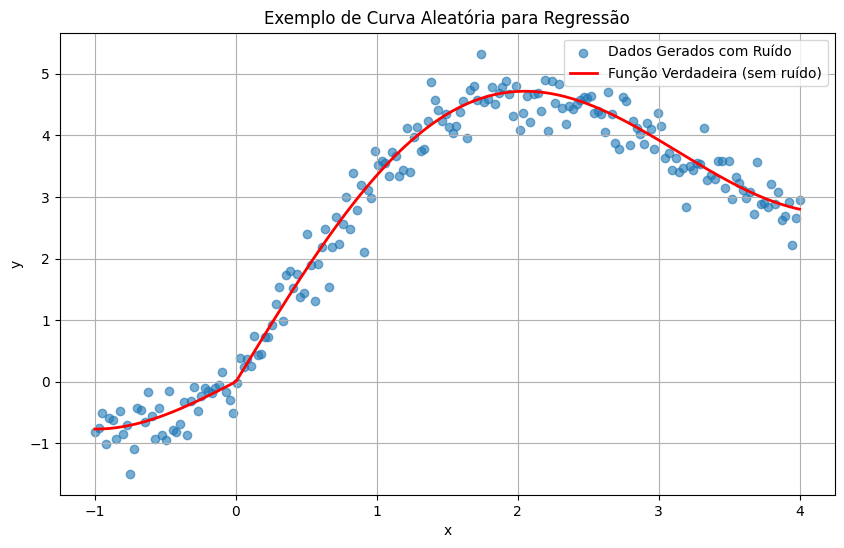

In [65]:

# Instanciar a classe
data_generator = RandomRegressionData()
# Gerar dados
X_data, y_data, func_str, func_terms = data_generator.generate_random_regression_data(n_samples=200, noise=0.3)

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_data, y_data, alpha=0.6, label='Dados Gerados com Ruído')

y_true = data_generator.evaluate_function(X_data, func_terms)
plt.plot(X_data, y_true, 'r-', lw=2, label='Função Verdadeira (sem ruído)')

plt.title("Exemplo de Curva Aleatória para Regressão")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
print("Função gerada:", func_str)
plt.show()


### Exercício 7: Compare sua implementação com PyTorch ou JAX

Agora que você construiu e treinou um framework do zero, é hora de apreciar o poder e a conveniência das bibliotecas modernas de Deep Learning.

**A Tarefa:**

Escolha um dos problemas de classificação tratados hoje (e.g., "Duas Luas" ou "Círculos Concêntricos") e desenvolva uma nova implementação para resolvê-lo usando **PyTorch** ou **JAX**.

**O que comparar:**

* **Complexidade do Código:** Compare a quantidade de código necessária para definir o modelo, o custo e o loop de treinamento na sua implementação NumPy vs. a do framework.
* **Facilidade de Uso:** Quão mais fácil foi gerenciar os gradientes, os parâmetros e a atualização dos pesos?
* **Performance:** Houve diferença na velocidade de treinamento ou na acurácia final do modelo?

O objetivo é refletir sobre as abstrações que os frameworks modernos fornecem e entender o que está acontecendo "por baixo dos panos" quando você chama funções como `loss.backward()` e `optimizer.step()`.